In [2]:
import math

In [3]:

# Number of elemenbt in each class
n_A = 4
n_B = 6
total = n_A + n_B

In [4]:
# Calculate proportion
p_A = n_A / total
p_B = n_B / total

print("Proportion of A:", p_A)
print("Proportion of B:", p_B)

Proportion of A: 0.4
Proportion of B: 0.6


In [5]:
# Entropy Calculate
# Entropy is measure of uncertinaty
entropy = - (p_A * math.log2(p_A) + p_B * math.log2(p_B))
print(entropy)

0.9709505944546686


In [6]:
# Gini impurity same as entropy
# Gini impurity is measure of misclassification
gini_impurity = 1 - (p_A**2 + p_B**2)
print(gini_impurity)


0.48


In [8]:
# Information gain
# assuming a split on some features divides the dataset into two subsets
# Subsets 1: 2 elements of A, 3 of B
# Subsets 2: 2 elements of A, 3 of B
# Entropy and size for each subset
n_1_A, n_1_B = 2, 3
n_2_A, n_2_B = 2, 3

p_1_A = n_1_A / (n_1_A + n_1_B)
p_1_B = n_1_B / (n_1_A + n_1_B)
entropy_1 = -p_1_A * math.log2(p_1_A) - p_1_B * math.log2(p_1_B) if p_1_A and p_1_B else 0


p_2_A = n_2_A / (n_2_A + n_2_B)
p_2_B = n_2_B / (n_2_A + n_2_B)
entropy_2 = -p_2_A * math.log2(p_2_A) - p_2_B * math.log2(p_2_B) if p_2_A and p_2_B else 0


# calculating information gain
info_gain = entropy - ((n_1_A + n_1_B) / total * entropy_1 + (n_2_A + n_2_B) / total * entropy_2)

print("Information Gain:", info_gain)

Information Gain: 0.0


### Decision tree example in python

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


In [10]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
df.drop('deck', axis=1, inplace=True)


imputer = SimpleImputer(strategy='median')
df[['age', 'fare']] = imputer.fit_transform(df[['age', 'fare']])


imputer = SimpleImputer(strategy='most_frequent')
df[['embark_town', 'embarked']] = imputer.fit_transform(df[['embark_town', 'embarked']])


In [12]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [13]:
# encoding
le = LabelEncoder()

for col in df.select_dtypes(include=['object', 'category']):
    df[col] = le.fit_transform(df[col])


In [14]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


In [15]:
X = df.drop(['alive', 'survived'], axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
model = DecisionTreeClassifier(criterion='entropy',random_state=42, max_depth=5)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

In [29]:
print("confusion_matrix: ", confusion_matrix(y_test, y_pred))
print("classification_report:  ", classification_report(y_test, y_pred))

confusion_matrix:  [[92 13]
 [19 55]]
classification_report:                 precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



<Axes: >

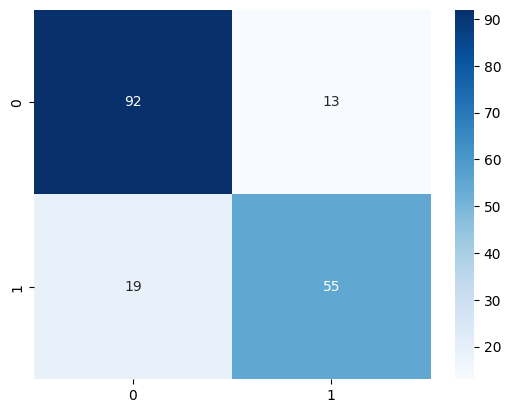

In [30]:
# plot confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

In [31]:
# save the classifier
from sklearn.tree import export_graphviz

export_graphviz(model, out_file="./saved_models/decision_tree_2.dot", feature_names=X.columns, rounded=True, filled=True)